In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [74]:
df = pd.read_csv("insurance.csv")

In [75]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [77]:
df.shape

(1338, 7)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


#encode krna hoga because numpy only works on numerical data set


##OHE

In [79]:
df = pd.get_dummies(df, drop_first = True)  #categorical columns ko numerical bna dega ye

In [80]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [81]:
X = df.drop('charges', axis = 1)
y = df['charges']

In [82]:
print(X.head())
print()
print(y.head())

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [83]:
X = df.drop("charges", axis = 1)  #axis = 1 : columns per operation kro

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

Feature Scaling

In [86]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [87]:
weights = np.zeros(X_train.shape[1])
bias = 0

Prediction Function


In [88]:
def predict(X, weights, bias):
  return np.dot(X, weights) + bias  #formula for multiple linear regression

MSE Function

In [89]:
def compute_loss(y_true, y_pred):
  return np.mean((y_true - y_pred) ** 2)   #errors ka square nikala hai

In [90]:
def update_parameters(weights, bias, dw, db, learning_rate):
  weights = weights - learning_rate * dw
  bias = bias - learning_rate * db
  return weights, bias

In [91]:
learning_rate = 0.01
epochs = 1000

losses = []

for epoch in range(epochs):
  y_pred = predict(X_train, weights, bias)
  loss = compute_loss(y_train, y_pred)
  losses.append(loss)

  n = len(y_train)

  dw = (1/n) * np.dot(X_train.T, (y_pred - y_train))
  db = (1/n) * np.sum(y_pred - y_train)

  weights, bias = update_parameters(weights, bias, dw, db, learning_rate)

  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss: {loss:0.2f}")

Epoch 0, Loss: 322451733.18
Epoch 100, Loss: 76034210.09
Epoch 200, Loss: 42675598.76
Epoch 300, Loss: 38051677.18
Epoch 400, Loss: 37395687.22
Epoch 500, Loss: 37298735.16
Epoch 600, Loss: 37282862.91
Epoch 700, Loss: 37279549.90
Epoch 800, Loss: 37278538.17
Epoch 900, Loss: 37278113.39


In [92]:
y_pred_test = predict(X_test, weights, bias)

TEST MSE

In [93]:
test_loss = compute_loss(y_test, y_pred_test)
print("Test MSE:", test_loss)

Test MSE: 33608763.19068821


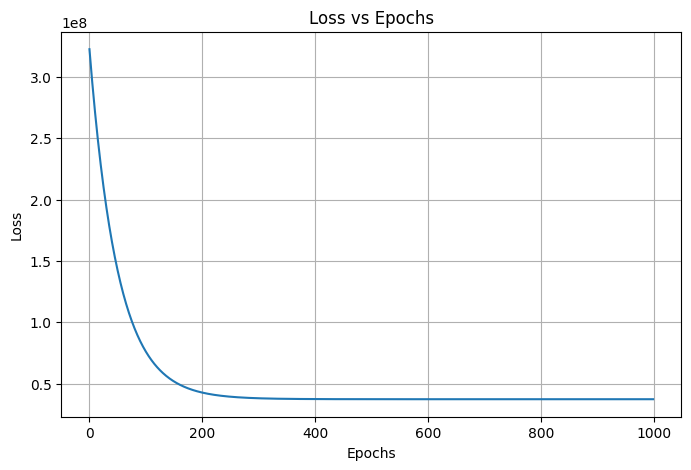

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

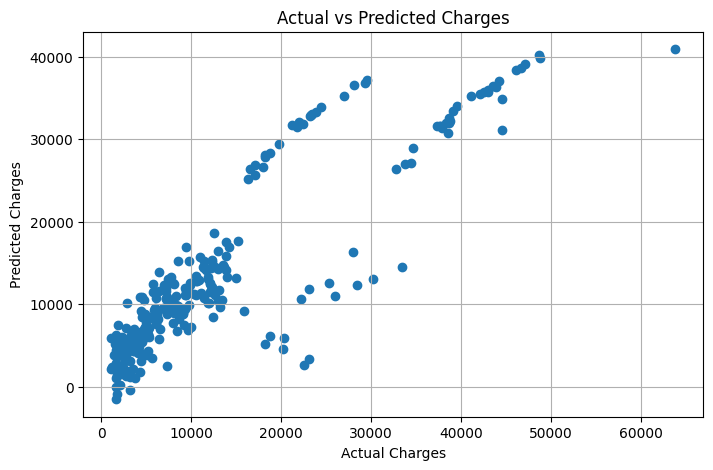

In [95]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.grid(True)
plt.show()

Scikit-Learn Model

In [96]:
from sklearn.linear_model import LinearRegression


In [97]:
model = LinearRegression()
model.fit(X_train, y_train)

sk_pred = model.predict(X_test)

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Numpy Model")
print("MSE :", test_loss);
print()
print("Scikit-Learn Model")
print("MAE :", mean_absolute_error(y_test, sk_pred))

print("MSE: ", mean_squared_error(y_test, sk_pred))


Numpy Model
MSE : 33608763.19068821

Scikit-Learn Model
MAE : 4181.194473753651
MSE:  33596915.851361476


In [99]:
print("Numpy weights: ")
print(weights)

print()

print("Scikit-Learn coefficients: ")
print(model.coef_)

print()

print("Numpy Bias: ")
print(bias)

print()

print("Scikit-Learn Bias: ")
print(model.intercept_)

Numpy weights: 
[ 3.61488185e+03  2.03241312e+03  5.16980755e+02 -8.70529765e+00
  9.55789194e+03 -1.43936208e+02 -2.74066666e+02 -3.34265195e+02]

Scikit-Learn coefficients: 
[ 3.61497541e+03  2.03622812e+03  5.16890247e+02 -9.29310107e+00
  9.55848141e+03 -1.58140981e+02 -2.90157047e+02 -3.49110678e+02]

Numpy Bias: 
13345.513569022516

Scikit-Learn Bias: 
13346.089736364485


In [100]:
comparison = pd.DataFrame({"Actual ": y_test.values, "Numpy Prediction ": sk_pred})
print(comparison.head(10))

       Actual   Numpy Prediction 
0   9095.06825        8969.550274
1   5272.17580        7068.747443
2  29330.98315       36858.410912
3   9301.89355        9454.678501
4  33750.29180       26973.173457
5   4536.25900       10864.113164
6   2117.33885         170.280841
7  14210.53595       16903.450287
8   3732.62510        1092.430936
9  10264.44210       11218.343184
